In [79]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [61]:
data = pd.read_csv("Smart_Cluster_System/smartcluster.csv")

In [62]:
data

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,42,118,247,2,9,3,4,5,0,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,0,0,8,7,8,2,5,7,0,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,32,12,24,1,2,3,13,6,0,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,80,30,61,2,6,5,10,3,0,0


In [63]:
data.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

In [64]:
data["Income"]=data["Income"].fillna(data["Income"].median())

##data processing

In [65]:
data

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,42,118,247,2,9,3,4,5,0,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,0,0,8,7,8,2,5,7,0,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,32,12,24,1,2,3,13,6,0,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,80,30,61,2,6,5,10,3,0,0


In [87]:
data["Dt_Customer"]=pd.to_datetime(data["Dt_Customer"],dayfirst=True)
reference_date=data["Dt_Customer"].max()
data["tenure"]=(reference_date-data["Dt_Customer"]).dt.days
data["Age"]=2026-data["Year_Birth"]

In [88]:
data

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,tenure,total_children,total_spending,living_with,Age
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,663,0,1705,Alone,69
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,113,2,28,Alone,72
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,312,0,797,Partner,61
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,139,1,56,Partner,42
4,5324,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,161,1,449,Married,45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduate,Married,61223.0,0,1,2013-06-13,46,709,...,3,4,5,0,0,381,1,1459,Married,59
2236,4001,1946,Postgraduate,Together,64014.0,2,1,2014-06-10,56,406,...,2,5,7,0,0,19,3,444,Partner,80
2237,7270,1981,Graduate,Divorced,56981.0,0,0,2014-01-25,91,908,...,3,13,6,0,0,155,0,1253,Alone,45
2238,8235,1956,Postgraduate,Together,69245.0,0,1,2014-01-24,8,428,...,5,10,3,0,0,156,1,873,Partner,70


In [89]:
data.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'tenure', 'total_children', 'total_spending',
       'living_with', 'Age'],
      dtype='str')

## colums

In [90]:
data["total_children"]=data["Kidhome"]+data["Teenhome"]
data["total_spending"]=data["MntMeatProducts"]+data["MntFishProducts"]+data["MntFruits"]+data["MntSweetProducts"]+data["MntWines"]+data["MntSweetProducts"]+data["MntGoldProds"]

In [91]:
data

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,tenure,total_children,total_spending,living_with,Age
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,663,0,1705,Alone,69
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,113,2,28,Alone,72
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,312,0,797,Partner,61
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,139,1,56,Partner,42
4,5324,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,161,1,449,Married,45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduate,Married,61223.0,0,1,2013-06-13,46,709,...,3,4,5,0,0,381,1,1459,Married,59
2236,4001,1946,Postgraduate,Together,64014.0,2,1,2014-06-10,56,406,...,2,5,7,0,0,19,3,444,Partner,80
2237,7270,1981,Graduate,Divorced,56981.0,0,0,2014-01-25,91,908,...,3,13,6,0,0,155,0,1253,Alone,45
2238,8235,1956,Postgraduate,Together,69245.0,0,1,2014-01-24,8,428,...,5,10,3,0,0,156,1,873,Partner,70


In [92]:
data["Education"] = data["Education"].replace({
    "Basic": "Undergraduate",
    "2n Cycle": "Undergraduate",
    "Graduation": "Graduate",
    "Master": "Postgraduate",
    "PhD": "Postgraduate"
})

In [93]:
data["living_with"] = data["Marital_Status"].replace({
    "Widow": "Alone",
    "YOLO": "Alone",
    "Together": "Partner",
    "Maried": "Partner",
    "Single": "Alone",
    "Absurd":"Alone",
    "Divorced":"Alone"
})

In [94]:
data.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'tenure', 'total_children', 'total_spending',
       'living_with', 'Age'],
      dtype='str')

In [95]:
df=data.drop(["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer","MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"],axis=1)


In [96]:
df

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,tenure,total_children,total_spending,living_with,Age
0,Graduate,58138.0,58,3,8,10,4,7,0,1,663,0,1705,Alone,69
1,Graduate,46344.0,38,2,1,1,2,5,0,0,113,2,28,Alone,72
2,Graduate,71613.0,26,1,8,2,10,4,0,0,312,0,797,Partner,61
3,Graduate,26646.0,26,2,2,0,4,6,0,0,139,1,56,Partner,42
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,161,1,449,Married,45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,Graduate,61223.0,46,2,9,3,4,5,0,0,381,1,1459,Married,59
2236,Postgraduate,64014.0,56,7,8,2,5,7,0,0,19,3,444,Partner,80
2237,Graduate,56981.0,91,1,2,3,13,6,0,0,155,0,1253,Alone,45
2238,Postgraduate,69245.0,8,2,6,5,10,3,0,0,156,1,873,Partner,70


In [97]:
df.shape

(2240, 15)

## detecting outliers

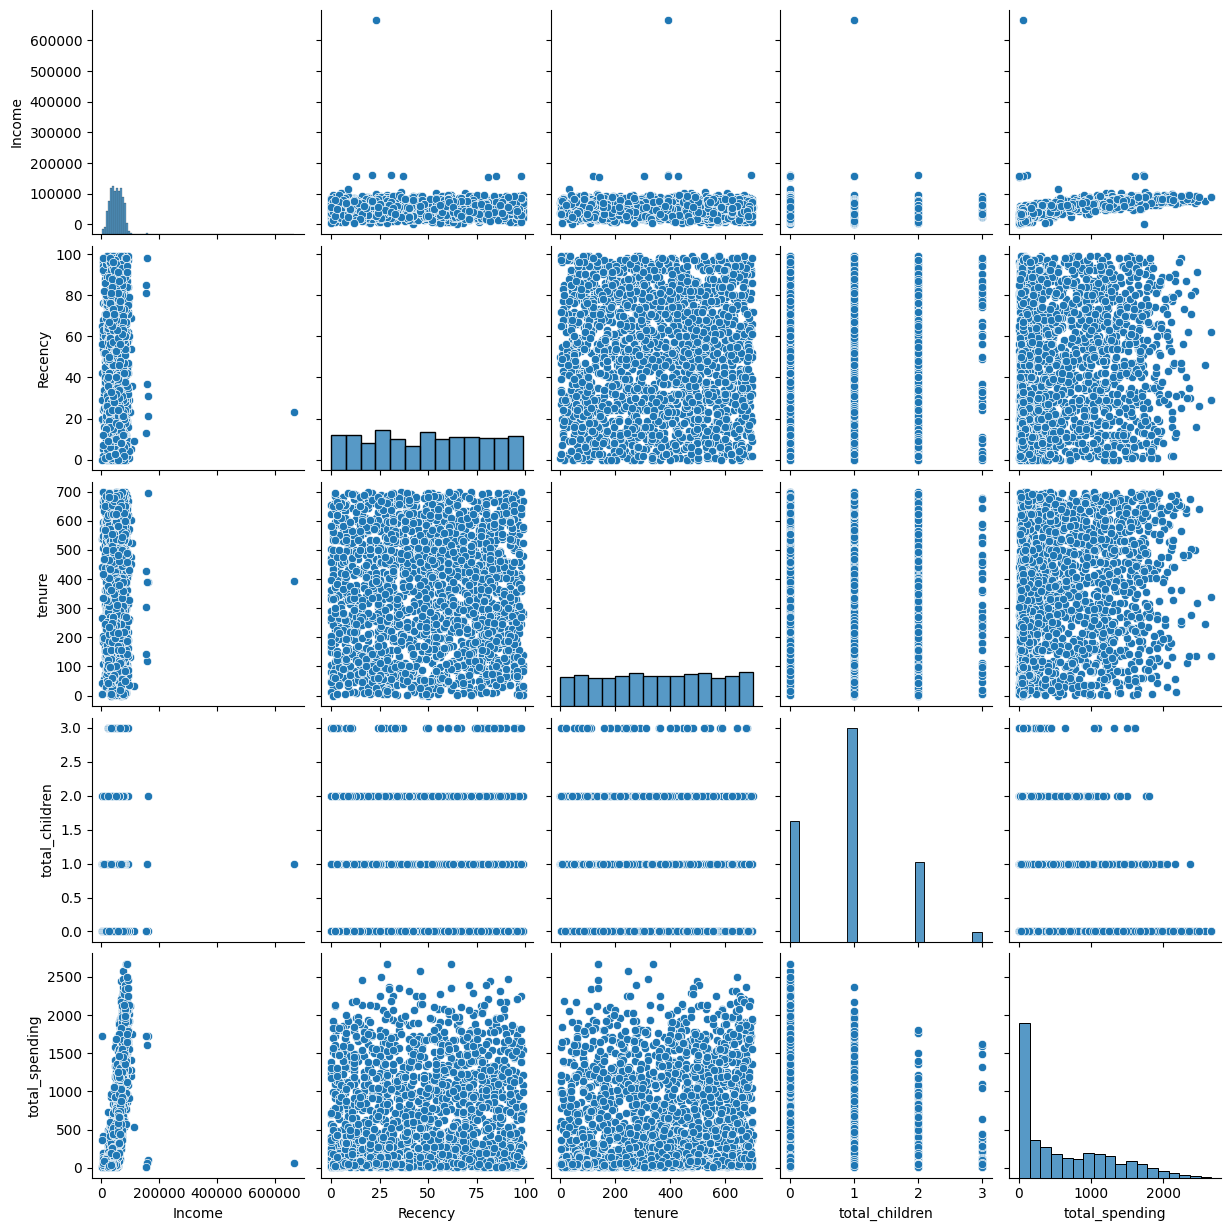

In [98]:
cols=['Education','Income',"Recency","tenure",'total_children',"total_spending","living_with"]
sns.pairplot(df[cols])

In [101]:
df=df[ (df["Age"]<90) ]
df=df[ (df["Income"]<600_000) ]

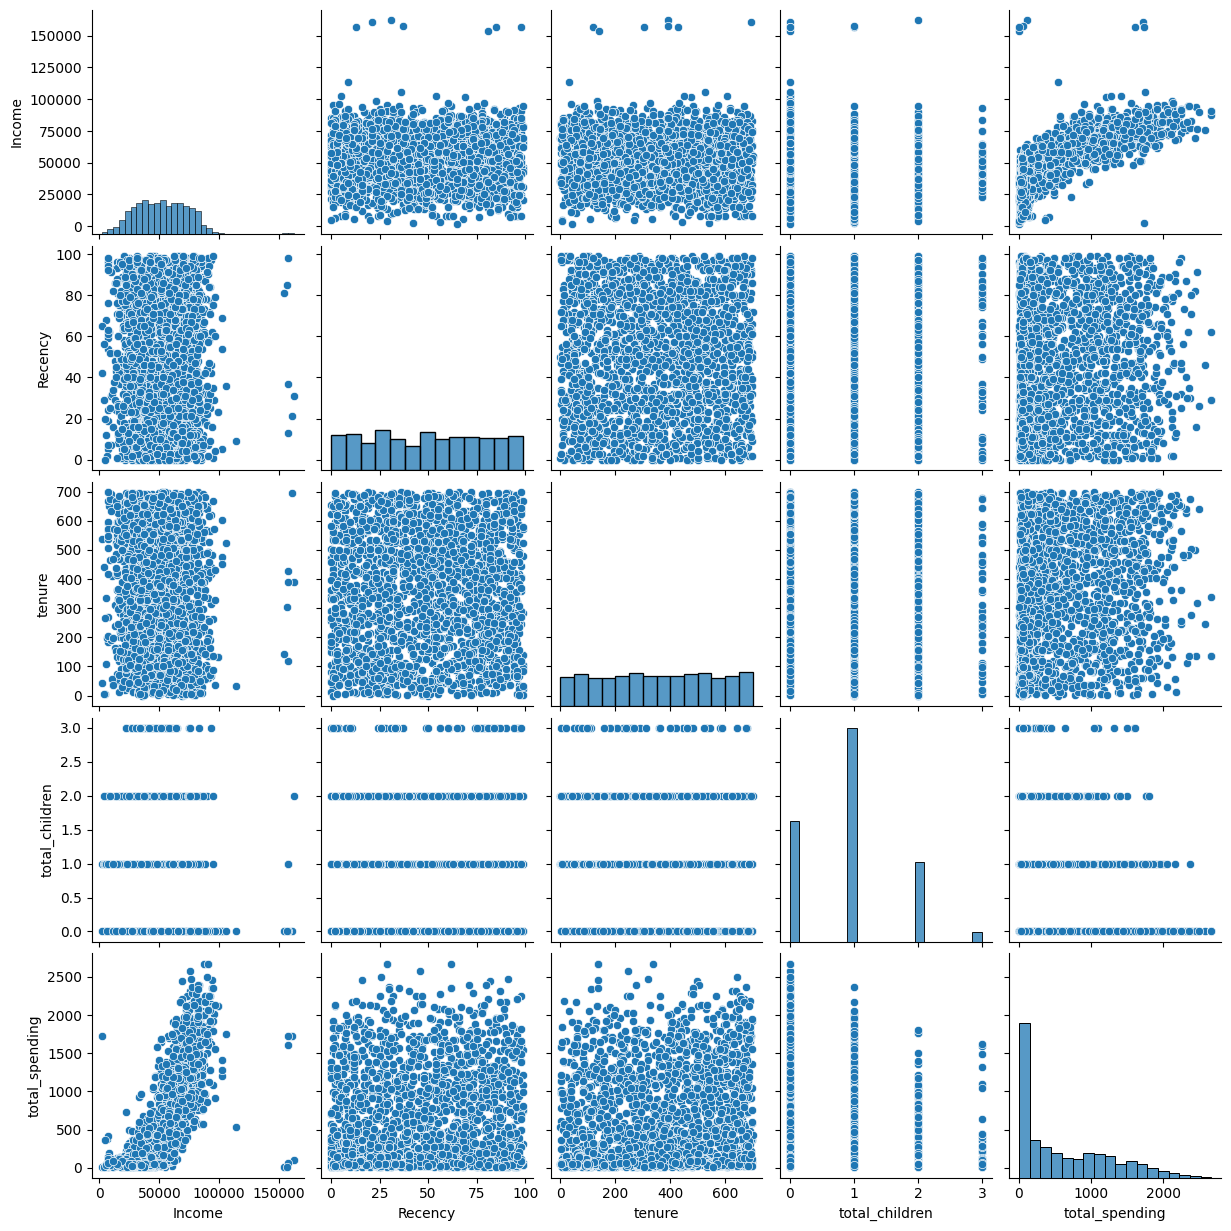

In [103]:
sns.pairplot(df[cols])

<Axes: >

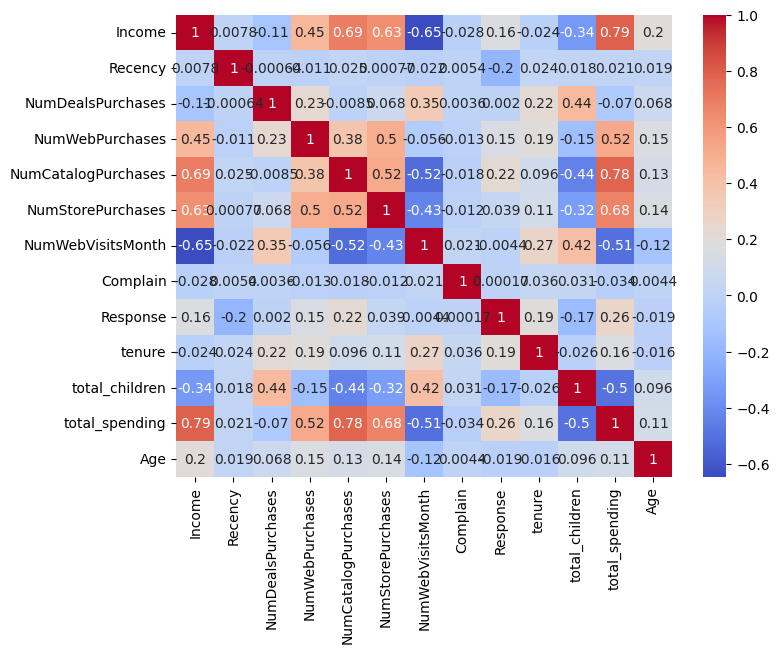

In [111]:
corr=df.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True
)

## encoding

In [123]:
df.columns

Index(['Education', 'Income', 'Recency', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'Complain', 'Response', 'tenure', 'total_children',
       'total_spending', 'living_with', 'Age'],
      dtype='str')

In [159]:
from sklearn.preprocessing import OneHotEncoder
ohe=OneHotEncoder()
cols = ["Education","living_with"]
enc=ohe.fit_transform(df[cols])

enc_df = pd.DataFrame(enc.toarray(),columns=ohe.get_feature_names_out(cols),index=df.index)
df_encoded = pd.concat(
    [df.drop(["Education", "living_with"], axis=1), enc_df],
    axis=1
)

In [160]:
df_encoded

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,tenure,total_children,total_spending,Age,Education_Graduate,Education_Postgraduate,Education_Undergraduate,living_with_Alone,living_with_Married,living_with_Partner
0,58138.0,58,3,8,10,4,7,0,1,663,0,1705,69,1.0,0.0,0.0,1.0,0.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,113,2,28,72,1.0,0.0,0.0,1.0,0.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,312,0,797,61,1.0,0.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,139,1,56,42,1.0,0.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,161,1,449,45,0.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,61223.0,46,2,9,3,4,5,0,0,381,1,1459,59,1.0,0.0,0.0,0.0,1.0,0.0
2236,64014.0,56,7,8,2,5,7,0,0,19,3,444,80,0.0,1.0,0.0,0.0,0.0,1.0
2237,56981.0,91,1,2,3,13,6,0,0,155,0,1253,45,1.0,0.0,0.0,1.0,0.0,0.0
2238,69245.0,8,2,6,5,10,3,0,0,156,1,873,70,0.0,1.0,0.0,0.0,0.0,1.0


In [173]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

x= df_encoded.drop(columns=["Response"])

x_scaled=scaler.fit_transform(x)


In [174]:
from sklearn.decomposition import PCA

In [175]:
pca = PCA(n_components=3)
x_pca = pca.fit_transform(x_scaled)

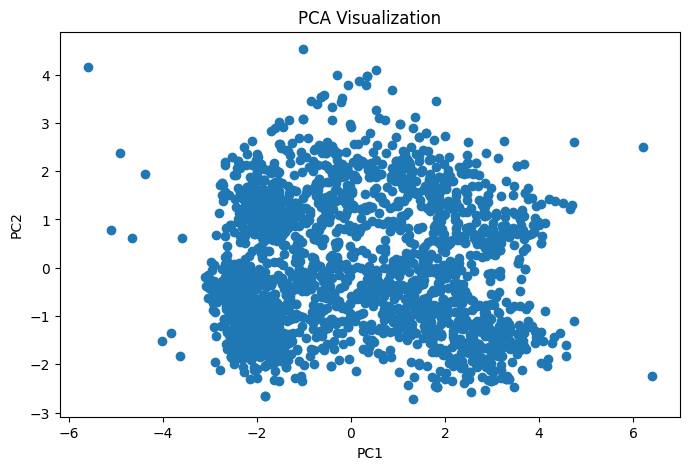

In [182]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    x_pca[:, 0],
    x_pca[:, 1]
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Visualization")
plt.show()

In [183]:
x_scaled.shape

(2236, 18)

In [184]:
pca.explained_variance_ratio_

array([0.22903049, 0.10366419])

## elbow methrod

In [192]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit_predict(x_pca)
    wcss.append(kmeans.inertia_)
    

In [193]:
knee = KneeLocator(range(1, 11), wcss, curve="convex", direction="decreasing")
optimal_k = knee.elbow

In [194]:
print("best k =", optimal_k)

best k = 3


Text(0, 0.5, 'WCSS')

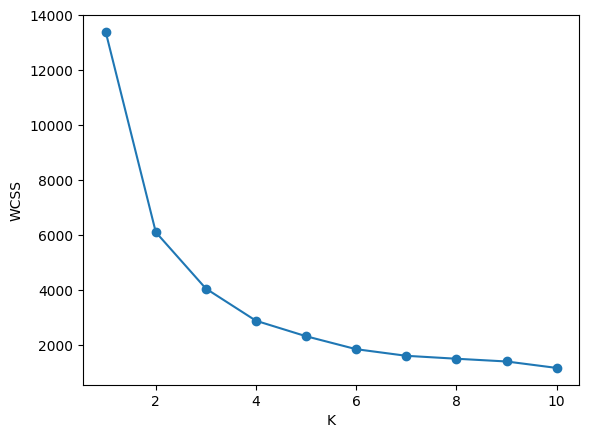

In [195]:
# plot

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("K")
plt.ylabel("WCSS")

## silhoutte

Text(0, 0.5, 'Silhouette score')

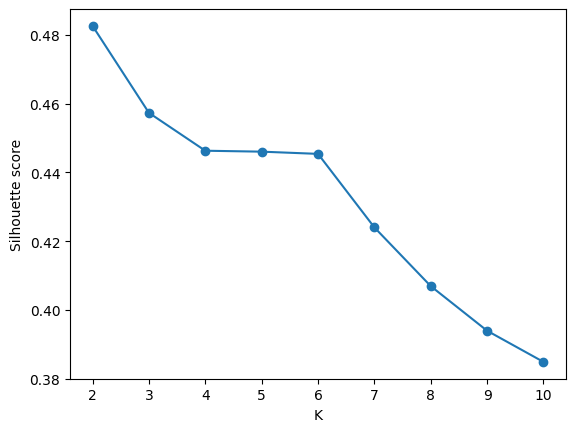

In [198]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(x_pca)
    score = silhouette_score(x_pca, labels)
    scores.append(score)

# plot
plt.plot(range(2, 11), scores, marker='o')
plt.xlabel("K")
plt.ylabel("Silhouette score")

Text(0, 0.5, 'SS')

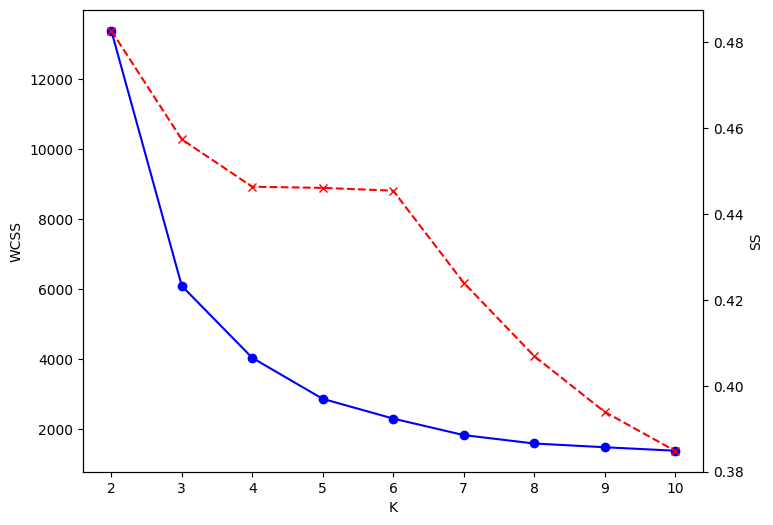

In [199]:
# combined plot

k_range = range(2, 11)

fig, ax1 = plt.subplots(figsize=(8, 6))

ax1.plot(k_range, wcss[:len(k_range)], marker="o", color="blue") 
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()
ax2.plot(k_range, scores[:len(k_range)], marker="x", color="red", linestyle="--")
ax2.set_ylabel("SS")

# final modelling agglomerative


In [201]:
# K_means

kmeans = KMeans(n_clusters=4, random_state=42)
labels_kmeans = kmeans.fit_predict(x_pca)

In [205]:
# Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering

In [207]:
agg_clf = AgglomerativeClustering(n_clusters=4, linkage="ward")
labels_agg = agg_clf.fit_predict(x_pca)

In [213]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
x_pca = pca.fit_transform(x_scaled)

print(x_pca.shape)

(2236, 3)


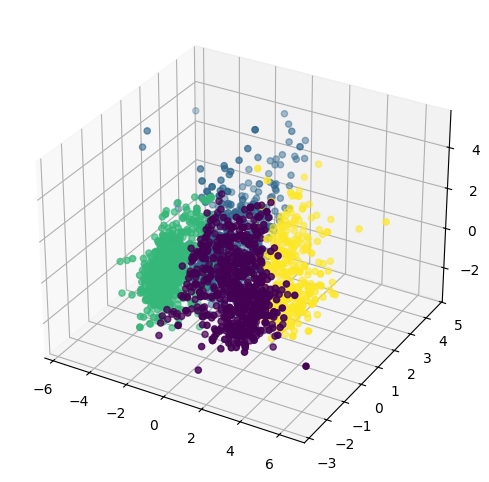

In [215]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(x_pca[:, 0], x_pca[:, 1], x_pca[:, 2], c=labels_agg)

# charecterization

In [216]:

x["cluster"] = labels_agg

In [220]:
x.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,tenure,total_children,total_spending,Age,Education_Graduate,Education_Postgraduate,Education_Undergraduate,living_with_Alone,living_with_Married,living_with_Partner
0,58138.0,58,3,8,10,4,7,0,663,0,1705,69,1.0,0.0,0.0,1.0,0.0,0.0
1,46344.0,38,2,1,1,2,5,0,113,2,28,72,1.0,0.0,0.0,1.0,0.0,0.0
2,71613.0,26,1,8,2,10,4,0,312,0,797,61,1.0,0.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,139,1,56,42,1.0,0.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,161,1,449,45,0.0,1.0,0.0,0.0,1.0,0.0


<Axes: xlabel='cluster', ylabel='count'>

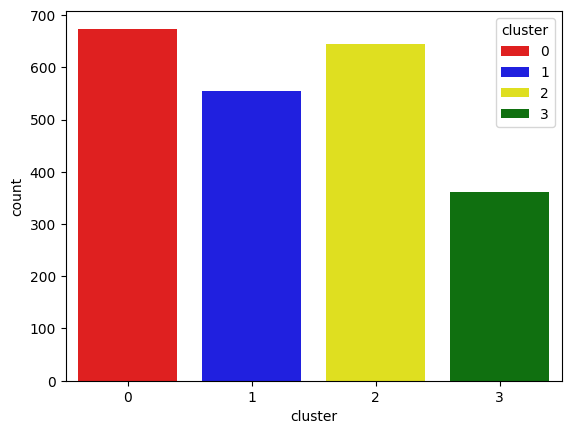

In [221]:
pal = ["red", "blue", "yellow", "green"]

sns.countplot(x=X["cluster"], palette=pal, hue=X["cluster"])

<Axes: xlabel='total_spending', ylabel='Income'>

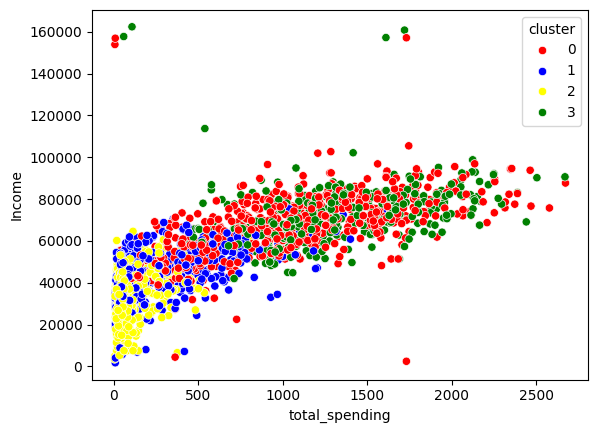

In [223]:
# Income & Spending patterns

sns.scatterplot(x=X["total_spending"], y=X["Income"], hue=X["cluster"], palette=pal)

In [225]:
print(x_scaled.shape)
print(x_pca.shape)
print(pca.explained_variance_ratio_)

(2236, 18)
(2236, 3)
[0.22903049 0.10366419 0.09876006]


In [226]:
# Cluster Summary

cluster_summary = X.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        67497.990356  50.114243           1.936202         5.351632   
1        43351.198198  48.019820           3.234234         3.641441   
2        31588.328682  49.579845           2.131783         2.102326   
3        72480.697514  48.113260           2.005525         5.955801   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   4.455490           7.851632           3.853116  0.010386   
1                   1.205405           4.448649           6.508108  0.000000   
2                   0.480620           3.113178           6.717829  0.018605   
3                   5.450276           8.812155           3.732044  0.002762   

             tenure  total_children  total_spending        Age  \
cluster             